# Análise Exploratória de Dados — CAGED (Curitiba e RMC)

**Fonte:** Novo CAGED — Ministério do Trabalho e Emprego  
**Objetivo:** Explorar os microdados de movimentação (admissões e desligamentos) da Região Metropolitana de Curitiba, compreendendo distribuições, relações entre variáveis e qualidade dos dados, como subsídio para a etapa de modelagem preditiva da coluna `saldomovimentacao`.

---

**Sumário**
- 1 Importações e Configurações
- 2 Análise Exploratória de Dados
    - 2.1 Carregamento e Visão Geral
    - 2.2 Qualidade dos Dados (nulos, duplicatas, tipos)
    - 2.3 Variável-Alvo: `saldomovimentacao`
    - 2.4 Análise Temporal
    - 2.5 Análise Geográfica (Municípios)
    - 2.6 Análise Setorial (Seção CNAE)
    - 2.7 Análise Demográfica (Sexo, Raça/Cor, Escolaridade, Idade)
    - 2.8 Análise Salarial
    - 2.9 Variáveis de Trabalho (Horas, Tipo de Empregador, Deficiência, etc.)
    - 2.10 Matriz de Correlação
    - 2.11 Análise Bivariada com a Variável-Alvo
    - 2.12 Conclusões e Insights

## 1 Importações e Configurações

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

### Configurações

In [91]:
# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

# Configurações do pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.expand_frame_repr", False)

SEED = 42

### Dicionários de domínio
Mapeamentos dos códigos para descrições legíveis, baseados na documentação oficial do CAGED.

In [92]:
MAP_REGIAO = {1: "Norte", 2: "Nordeste", 3: "Sudeste", 4: "Sul", 5: "Centro-Oeste"}

MAP_SEXO = {1: "Masculino", 3: "Feminino", 2: "Ignorado", 0: "?"}

MAP_RACA_COR = {
    1: "Branca", 2: "Preta", 3: "Parda",
    4: "Amarela", 5: "Indígena", 6: "Não informada",
    9: "Não informada", 0: "?",
}

MAP_GRAU_INSTRUCAO = {
    0: "?", 1: "Analfabeto", 2: "Até 5ª inc.", 3: "5ª completa",
    4: "6ª-9ª inc.", 5: "Fund. Completo", 6: "Médio Inc.",
    7: "Médio Completo", 8: "Superior Inc.", 9: "Superior Completo",
    10: "Mestrado", 11: "Doutorado",
}

MAP_SALDO = {1: "Admissão", -1: "Desligamento"}

MAP_TIPO_ESTABELECIMENTO = {0: "?", 1: "CNPJ", 2: "CPF", 3: "CAEPF", 4: "CNO"}

MAP_TIPO_EMPREGADOR = {0: "?", 1: "Pessoa Jurídica", 2: "Pessoa Física", 3: "CEI", 4: "CAEPF"}

MAP_DEFICIENCIA = {
    0: "Sem deficiência", 1: "Física", 2: "Auditiva",
    3: "Visual", 4: "Intelectual", 5: "Múltipla", 9: "Não informado",
}

MAP_TAM_ESTAB = {
    0: "?", 1: "Até 4", 2: "5-9", 3: "10-19",
    4: "20-49", 5: "50-99", 6: "100-249", 7: "250-999",
    8: "1000+", 9: "1000+", 10: "1000+",
}

MAP_UNID_SALARIO = {1: "Hora", 2: "Dia", 3: "Semana", 4: "Quinzena", 5: "Mensal", 6: "Tarefa", 7: "Outros"}

print("Dicionários carregados.")

Dicionários carregados.


## 2 Análise Exploratória de Dados

## 2. Carregamento e Visão Geral

In [93]:
DATASET_PATH = Path("caged_curitiba_consolidado_train.csv")

df = pd.read_csv(DATASET_PATH, dtype=str)

print(f"Tamanho do Dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

print(f"\nColunas: {list(df.columns)}")

Tamanho do Dataset: 742,427 linhas × 26 colunas

Colunas: ['competenciamov', 'regiao', 'uf', 'municipio', 'secao', 'subclasse', 'saldomovimentacao', 'cbo2002ocupacao', 'categoria', 'graudeinstrucao', 'idade', 'horascontratuais', 'racacor', 'sexo', 'tipoempregador', 'tipoestabelecimento', 'tipodedeficiencia', 'indtrabintermitente', 'indtrabparcial', 'salario', 'tamestabjan', 'indicadoraprendiz', 'origemdainformacao', 'competenciadec', 'unidadesalariocodigo', 'valorsalariofixo']


In [94]:
# Conversão de tipos
int_cols = [
    "competenciamov", "regiao", "uf", "municipio", "saldomovimentacao",
    "cbo2002ocupacao", "categoria", "graudeinstrucao", "idade",
    "racacor", "sexo", "tipoempregador", "tipoestabelecimento",
    "tipodedeficiencia", "indtrabintermitente", "indtrabparcial",
    "tamestabjan", "indicadoraprendiz", "origemdainformacao",
    "competenciadec", "unidadesalariocodigo",
]

float_cols = ["salario", "valorsalariofixo"]

for c in int_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

# horascontratuais pode ter vírgula como separador decimal
df["horascontratuais"] = (
    df["horascontratuais"]
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

for c in float_cols:
    df[c] = (
        df[c]
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

df.head(3)

,competenciamov,regiao,uf,municipio,secao,subclasse,saldomovimentacao,cbo2002ocupacao,categoria,graudeinstrucao,idade,horascontratuais,racacor,sexo,tipoempregador,tipoestabelecimento,tipodedeficiencia,indtrabintermitente,indtrabparcial,salario,tamestabjan,indicadoraprendiz,origemdainformacao,competenciadec,unidadesalariocodigo,valorsalariofixo
0,202301,4,41,410690,S,9420100,1,411010,101,9,28,40.00,1,3,0,1,0,0,0,2935.24,7,0,1,202401,1,5.00
1,202301,4,41,410690,Q,8800600,1,515305,101,9,33,8.00,2,1,0,1,0,0,0,900.00,4,0,1,202401,1,5.00
2,202301,4,41,410690,G,4520005,1,519935,101,7,51,44.00,1,1,0,1,0,0,0,1540.00,3,0,1,202401,1,5.00


In [95]:
df.dtypes

competenciamov            Int64
regiao                    Int64
uf                        Int64
municipio                 Int64
secao                       str
subclasse                   str
saldomovimentacao         Int64
cbo2002ocupacao           Int64
categoria                 Int64
graudeinstrucao           Int64
idade                     Int64
horascontratuais        float64
racacor                   Int64
sexo                      Int64
tipoempregador            Int64
tipoestabelecimento       Int64
tipodedeficiencia         Int64
indtrabintermitente       Int64
indtrabparcial            Int64
salario                 float64
tamestabjan               Int64
indicadoraprendiz         Int64
origemdainformacao        Int64
competenciadec            Int64
unidadesalariocodigo      Int64
valorsalariofixo        float64
dtype: object

In [96]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
competenciamov,742427.00,<NA>,<NA>,<NA>,202458.61,50.43,202301.00,202411.00,202501.00,202511.00,202512.00
regiao,742427.00,<NA>,<NA>,<NA>,4.00,0.00,4.00,4.00,4.00,4.00,4.00
uf,742427.00,<NA>,<NA>,<NA>,41.00,0.00,41.00,41.00,41.00,41.00,41.00
municipio,742427.00,<NA>,<NA>,<NA>,410964.56,642.80,410180.00,410690.00,410690.00,410690.00,412550.00
secao,742427,22,N,224371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subclasse,742427,1037,7820500,73389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saldomovimentacao,742427.00,<NA>,<NA>,<NA>,-0.02,1.00,-1.00,-1.00,-1.00,1.00,1.00
cbo2002ocupacao,742427.00,<NA>,<NA>,<NA>,536699.54,177614.17,10105.00,414140.00,514320.00,716305.00,999999.00
categoria,742427.00,<NA>,<NA>,<NA>,101.89,7.72,101.00,101.00,101.00,101.00,999.00
graudeinstrucao,742427.00,<NA>,<NA>,<NA>,7.52,7.32,1.00,7.00,7.00,7.00,99.00


## 3. Qualidade dos Dados

### 3.1 Valores ausentes

In [97]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({"Ausentes": nulos, "%": nulos_pct}).query("Ausentes > 0").sort_values("%", ascending=False)

if resumo_nulos.empty:
    print("Nenhum valor ausente encontrado.")
else:
    display(resumo_nulos)

,Ausentes,%
idade,3,0.00


### 3.2 Duplicatas

In [98]:
n_dup = df.duplicated().sum()
print(f"Linhas duplicadas exatas: {n_dup:,} ({n_dup / len(df) * 100:.2f}%)")

Linhas duplicadas exatas: 42,549 (5.73%)


### 3.3 Valores únicos por coluna

In [99]:
unicos = df.nunique().sort_values(ascending=False)
display(unicos.to_frame("n_unicos"))

,n_unicos
salario,60506
cbo2002ocupacao,1843
horascontratuais,1102
subclasse,1037
idade,76
competenciamov,36
secao,22
municipio,16
graudeinstrucao,13
tamestabjan,10


### 3.4 Verificação de valores inesperados em variáveis categóricas

In [100]:
cat_checks = {
    "saldomovimentacao": {1, -1},
    "sexo": {1, 2, 3},
    "racacor": {1, 2, 3, 4, 5, 6, 9},
    "tipoempregador": {0, 1, 2, 3, 4},
    "tipodedeficiencia": {0, 1, 2, 3, 4, 5, 9},
    "indtrabintermitente": {0, 1},
    "indtrabparcial": {0, 1, 9},
    "indicadoraprendiz": {0, 1},
}

for col, esperados in cat_checks.items():
    reais = set(df[col].dropna().unique())
    inesperados = reais - esperados
    if inesperados:
        print(f"⚠ {col}: valores inesperados -> {inesperados}")
    else:
        print(f"✓ {col}: OK")

✓ saldomovimentacao: OK
⚠ sexo: valores inesperados -> {np.int64(9)}
✓ racacor: OK
✓ tipoempregador: OK
⚠ tipodedeficiencia: valores inesperados -> {np.int64(6)}
⚠ indtrabintermitente: valores inesperados -> {np.int64(9)}
✓ indtrabparcial: OK
✓ indicadoraprendiz: OK


## 4. Variável-Alvo: `saldomovimentacao`

O target é binário: **1** (admissão) ou **-1** (desligamento).

Distribuição da variável-alvo:
                   Contagem     %
saldomovimentacao                
Desligamento         378946 51.04
Admissão             363481 48.96


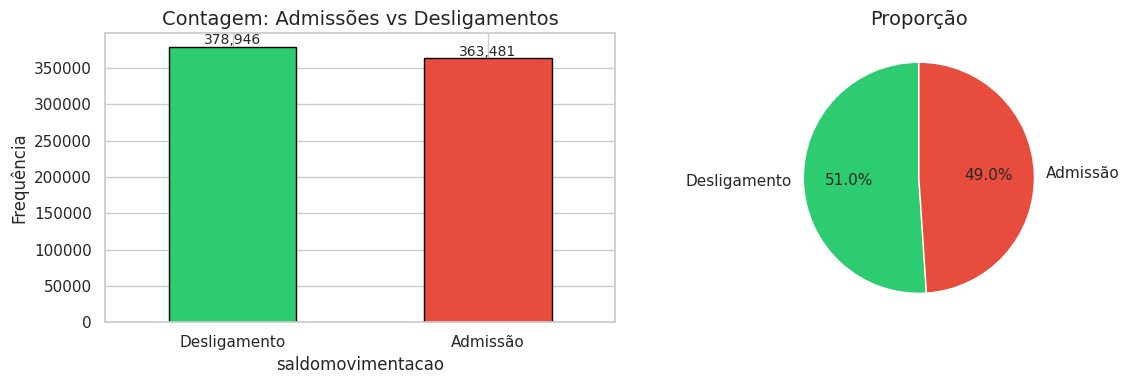


Razão entre classes: 1.04:1


In [101]:
saldo_counts = df["saldomovimentacao"].map(MAP_SALDO).value_counts()
saldo_pct = df["saldomovimentacao"].map(MAP_SALDO).value_counts(normalize=True) * 100

print("Distribuição da variável-alvo:")
print(pd.DataFrame({"Contagem": saldo_counts, "%": saldo_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#2ecc71", "#e74c3c"]
saldo_counts.plot.bar(ax=axes[0], color=colors, edgecolor="black")
axes[0].set_title("Contagem: Admissões vs Desligamentos")
axes[0].set_ylabel("Frequência")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(saldo_counts.values):
    axes[0].text(i, v + len(df) * 0.005, f"{v:,}", ha="center", fontsize=10)

saldo_counts.plot.pie(ax=axes[1], autopct="%1.1f%%", colors=colors,
                      startangle=90, textprops={"fontsize": 11})
axes[1].set_ylabel("")
axes[1].set_title("Proporção")

plt.tight_layout()
plt.show()

ratio = saldo_counts.max() / saldo_counts.min()
print(f"\nRazão entre classes: {ratio:.2f}:1")

## 5. Análise Temporal

In [102]:
# Volume total por competência
vol_mes = df.groupby("competenciamov").size().rename("total_movimentacoes")
print("Volume de movimentações por mês:")
display(vol_mes.to_frame())

print(f"\nMeses com dados: {df['competenciamov'].nunique()}")
print(f"Período: {df['competenciamov'].min()} a {df['competenciamov'].max()}")

Volume de movimentações por mês:


,total_movimentacoes
competenciamov,
202301,52
202302,35
202303,14
202304,11
202305,23
202306,22
202307,15
202308,34
202309,130



Meses com dados: 36
Período: 202301 a 202512


saldomovimentacao,Desligamento,Admissão,Saldo Líquido
competenciamov,,,
202301,11,41,30
202302,2,33,31
202303,8,6,-2
202304,4,7,3
202305,8,15,7
202306,11,11,0
202307,7,8,1
202308,11,23,12
202309,46,84,38


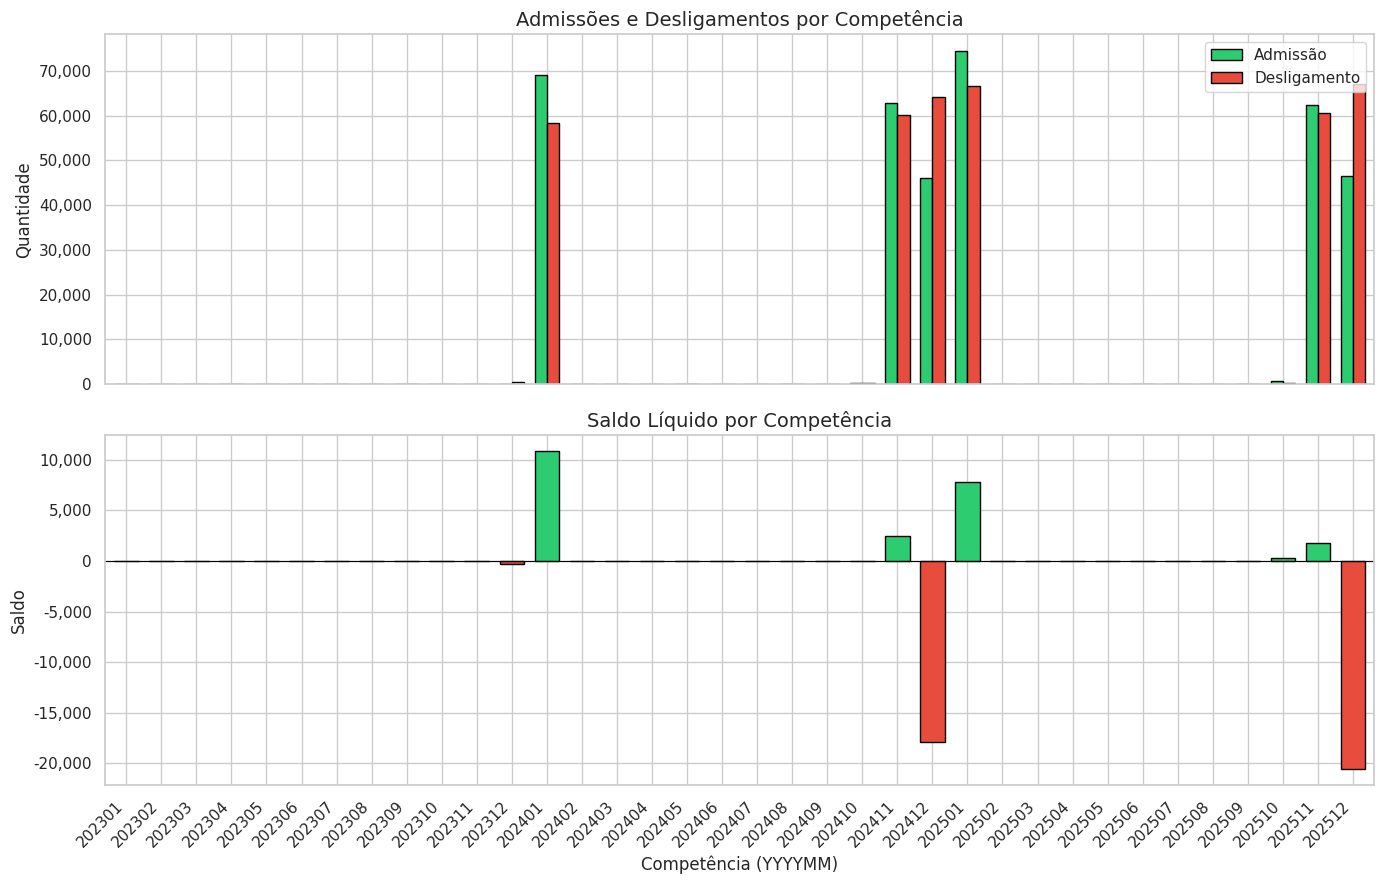

In [103]:
# Movimentações por competência
temp = (
    df.groupby(["competenciamov", "saldomovimentacao"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=MAP_SALDO)
)
temp["Saldo Líquido"] = temp.get("Admissão", 0) - temp.get("Desligamento", 0)

display(temp)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

temp[["Admissão", "Desligamento"]].plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="black", width=0.7)
axes[0].set_title("Admissões e Desligamentos por Competência")
axes[0].set_ylabel("Quantidade")
axes[0].legend(loc="upper right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

temp["Saldo Líquido"].plot.bar(
    ax=axes[1],
    color=["#2ecc71" if v >= 0 else "#e74c3c" for v in temp["Saldo Líquido"]],
    edgecolor="black", width=0.7,
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Saldo Líquido por Competência")
axes[1].set_ylabel("Saldo")
axes[1].set_xlabel("Competência (YYYYMM)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.1 Identificação dos meses relevantes

Conforme a descrição do trabalho, devem ser usados **novembro, dezembro e janeiro de 2024 e 2025**. Os demais meses existem na base e o professor recomenda entender o porquê e considerá-los com cautela.

In [104]:
# Extrair mês e ano para análise
df["ano"] = df["competenciamov"] // 100
df["mes"] = df["competenciamov"] % 100

meses_relevantes = {11, 12, 1}  # nov, dez, jan
df["mes_relevante"] = df["mes"].isin(meses_relevantes)

print("Distribuição por ano e mês:")
display(
    df.groupby(["ano", "mes"]).size().unstack(fill_value=0)
)

print(f"\nRegistros em meses relevantes (nov/dez/jan): {df['mes_relevante'].sum():,} ({df['mes_relevante'].mean()*100:.1f}%)")
print(f"Registros em outros meses: {(~df['mes_relevante']).sum():,} ({(~df['mes_relevante']).mean()*100:.1f}%)")

Distribuição por ano e mês:


mes,1,2,3,4,5,6,7,8,9,10,11,12
ano,,,,,,,,,,,,
2023,52,35,14,11,23,22,15,34,130,61,138,567
2024,127604,85,41,41,34,47,67,96,145,475,123069,110298
2025,141232,75,34,68,43,54,63,86,126,908,123012,113622



Registros em meses relevantes (nov/dez/jan): 739,594 (99.6%)
Registros em outros meses: 2,833 (0.4%)


## 6. Análise Geográfica (Municípios)

Total de municípios distintos: 16

Top 15 municípios por volume de movimentação:


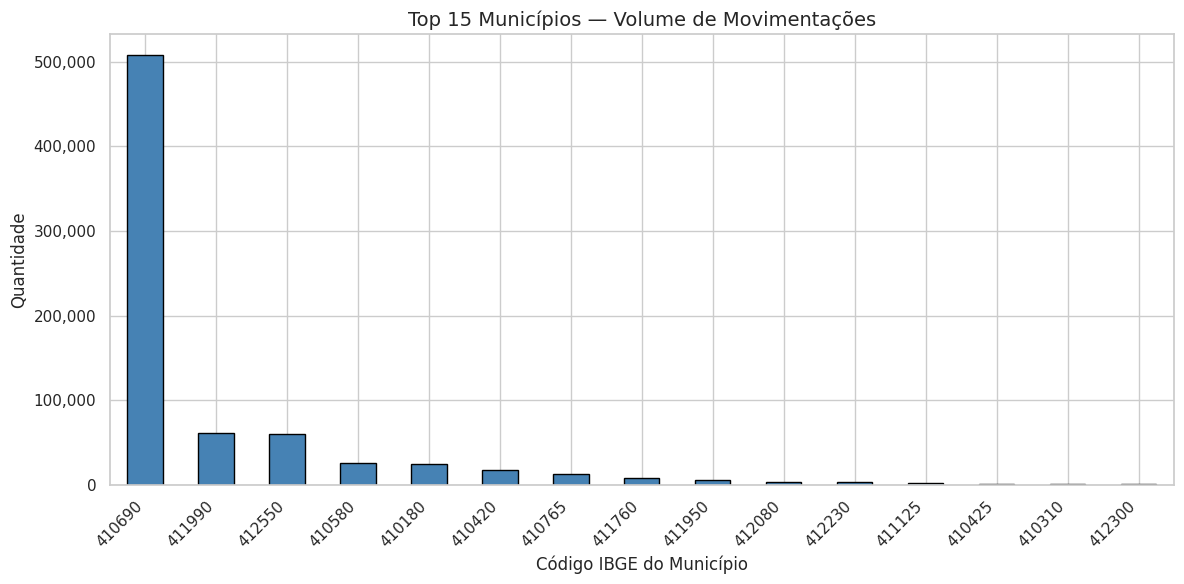


Curitiba (410690) representa 68.4% de todas as movimentações.


In [105]:
mun_counts = df["municipio"].value_counts()

print(f"Total de municípios distintos: {mun_counts.shape[0]}")
print(f"\nTop 15 municípios por volume de movimentação:")

top_mun = mun_counts.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_mun.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 15 Municípios — Volume de Movimentações")
ax.set_xlabel("Código IBGE do Município")
ax.set_ylabel("Quantidade")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Concentração
curitiba_share = mun_counts.get(410690, 0) / mun_counts.sum() * 100
print(f"\nCuritiba (410690) representa {curitiba_share:.1f}% de todas as movimentações.")

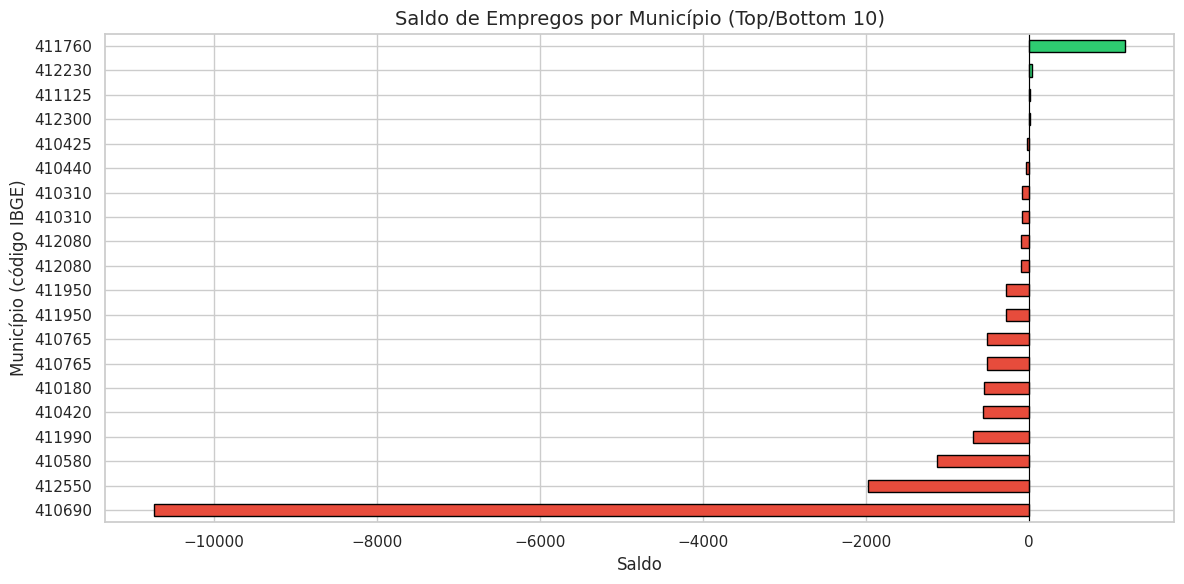

In [106]:
# Saldo por município (top e bottom)
saldo_mun = df.groupby("municipio")["saldomovimentacao"].sum().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
top_bottom = pd.concat([saldo_mun.head(10), saldo_mun.tail(10)]).sort_values()
cores = ["#e74c3c" if v < 0 else "#2ecc71" for v in top_bottom.values]
top_bottom.plot.barh(ax=ax, color=cores, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Saldo de Empregos por Município (Top/Bottom 10)")
ax.set_xlabel("Saldo")
ax.set_ylabel("Município (código IBGE)")
plt.tight_layout()
plt.show()

## 8. Análise Demográfica

### 8.1 Sexo

In [107]:
# ============================================================
# Preparação da variável
# ============================================================
col_original = "sexo"
mapa = MAP_SEXO
col_desc = f"{col_original}_desc"

df[col_desc] = df[col_original].map(mapa).fillna("?")

### 8.2 Raça/Cor

In [108]:
# ============================================================
# Preparação da variável
# ============================================================
col_original = "racacor"
mapa = MAP_RACA_COR
col_desc = f"{col_original}_desc"

df[col_desc] = df[col_original].map(mapa).fillna("?")

### 8.3 Grau de Instrução

In [ ]:
# ============================================================
# Preparação da variável
# ============================================================
col_original = "graudeinstrucao"
mapa = MAP_GRAU_INSTRUCAO
col_desc = f"{col_original}_desc"

df[col_desc] = df[col_original].map(mapa).fillna("?")

In [ ]:
# ============================================================
# Ordenação personalizada (mantendo hierarquia educacional)
# ============================================================
ordem_graudeinstrucao = (
    df[["graudeinstrucao", "graudeinstrucao_desc"]]
    .drop_duplicates()
    .sort_values("graudeinstrucao")["graudeinstrucao_desc"]
    .tolist()
)

### 8.4 Idade (Faixa Etária)

Optou-se por utilizar grupos quinquenais de idade, padrão amplamente adotado pelo IBGE (Instituto Brasileiro de Geografia e Estatística) em suas divulgações e metodologias demográficas, sendo considerado preferível por reduzir erros de declaração de idade e melhorar a consistência estatística.

**Referências:**
- [IBGE - Projeção da População](https://www.ibge.gov.br/estatisticas/sociais/populacao/9109-projecao-da-populacao.html?=&t=o-que-e)
- [IBGE - Grupos Quinquenais de Idade (Exemplo)](https://www.ibge.gov.br/estatisticas/sociais/populacao/9109-projecao-da-populacao.html?=&t=resultados#:~:text=grupos%20quiquenais)

In [ ]:
# ============================================================
# Estatísticas descritivas de idade
# ============================================================
print("Estatísticas de idade:")
display(df["idade"].describe().to_frame().T)

Estatísticas de idade:


,count,mean,std,min,25%,50%,75%,max
idade,742424.00,33.10,11.51,14.00,24.00,31.00,41.00,97.00


In [ ]:
# ============================================================
# Criação de faixas etárias (padrão quinquenal - IBGE)
# ============================================================
bins_idade = [
    0, 15, 20, 25, 30, 35, 40, 45, 50,
    55, 60, 65, 70, 75, 80, 85, 90, float("inf")
]

labels_idade = [
    "<15",
    "15-19", "20-24", "25-29", "30-34", "35-39",
    "40-44", "45-49", "50-54", "55-59",
    "60-64", "65-69", "70-74", "75-79",
    "80-84", "85-89", "90+"
]

col_desc = "faixa_etaria"
df["faixa_etaria"] = pd.cut(
    df["idade"],
    bins=bins_idade,
    labels=labels_idade,
    right=False
)

## 8.5 Análise Salarial

Optou-se por classificar os rendimentos do trabalho em faixas expressas em salários mínimos, seguindo a prática adotada pelo IBGE em suas séries estatísticas sobre mercado de trabalho. Especificamente, utilizam-se os intervalos 
- até 1/2 salário mínimo
- mais de 1/2 a 1
- de 1 a 2
- de 2 a 3 
- de 3 a 5
- de 5 a 10 
- de 10 a 20 
- acima de 20 salários mínimos

Esse tipo de agrupamento é amplamente empregado pelo IBGE por permitir maior comparabilidade temporal — ao neutralizar efeitos inflacionários — e por captar de forma mais precisa a distribuição dos rendimentos, especialmente nas faixas mais baixas e intermediárias, que concentram a maior parte da população ocupada. Além disso, a utilização de classes desiguais (mais detalhadas nas faixas inferiores e mais agregadas nas superiores) contribui para melhor representação da heterogeneidade da renda do trabalho.

Para a operacionalização empírica, adotou-se o valor do salário mínimo vigente em 2026 (R$ 1.621,00), a partir do qual foram construídas as faixas salariais utilizadas na análise.

**Referência:**

[IBGE – Séries Estatísticas: Empregados por classes de rendimento do trabalho principal (em salários mínimos)](https://seriesestatisticas.ibge.gov.br/series.aspx?no=2&op=1&t=empregados-rendimento-trabalho-principal-classes-rendimento&vcodigo=PD305)

In [ ]:
# ============================================================
# Parâmetro: salário mínimo (2026)
# ============================================================
salario_minimo = 1621.00

# ============================================================
# Estatísticas descritivas do salário
# ============================================================
print("Estatísticas do salário:")
display(df["salario"].describe().to_frame().T)

# ============================================================
# Criação de faixas salariais (padrão IBGE)
# ============================================================
bins_sal = [
    0,
    0.5 * salario_minimo,
    1 * salario_minimo,
    2 * salario_minimo,
    3 * salario_minimo,
    5 * salario_minimo,
    10 * salario_minimo,
    20 * salario_minimo,
    float("inf")
]

labels_sal = [
    "Até 0.5 SM",
    "0.5 a 1 SM",
    "1 a 2 SM",
    "2 a 3 SM",
    "3 a 5 SM",
    "5 a 10 SM",
    "10 a 20 SM",
    "20+ SM"
]

df["faixa_salarial"] = pd.cut(
    df["salario"],
    bins=bins_sal,
    labels=labels_sal,
    right=False
)


Estatísticas do salário:


,count,mean,std,min,25%,50%,75%,max
salario,742427.00,2319.34,5752.43,0.00,1685.25,1928.00,2300.00,1229200.00


saldomovimentacao,Admissão,Desligamento,Saldo
faixa_salarial,,,
Até 0.5 SM,8314,8854,-540
0.5 a 1 SM,60196,63591,-3395
1 a 2 SM,265006,269924,-4918
2 a 3 SM,19303,22511,-3208
3 a 5 SM,7079,9156,-2077
5 a 10 SM,2794,3776,-982
10 a 20 SM,529,872,-343
20+ SM,260,262,-2


---
---
---

## 10. Variáveis de Trabalho

### 10.2 Tamanho do Estabelecimento

saldomovimentacao,Desligamento,Admissão,Saldo
tam_estab_desc,,,
10-19,30424,27018,-3406
100-249,36081,32430,-3651
1000+,124565,118247,-6318
20-49,38611,34494,-4117
250-999,49281,46204,-3077
5-9,28774,25314,-3460
50-99,48757,45019,-3738
Até 4,22453,34755,12302


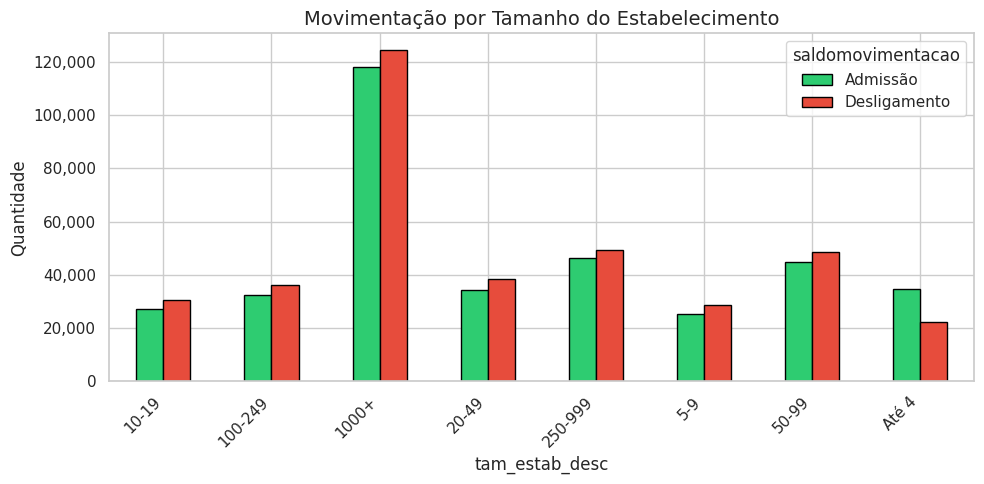

In [112]:
df["tam_estab_desc"] = df["tamestabjan"].map(MAP_TAM_ESTAB).fillna("?")

tam_saldo = (
    df.groupby(["tam_estab_desc", "saldomovimentacao"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=MAP_SALDO)
)
tam_saldo["Saldo"] = tam_saldo.get("Admissão", 0) - tam_saldo.get("Desligamento", 0)
display(tam_saldo)

fig, ax = plt.subplots(figsize=(10, 5))
tam_saldo[["Admissão", "Desligamento"]].plot.bar(
    ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="black",
)
ax.set_title("Movimentação por Tamanho do Estabelecimento")
ax.set_ylabel("Quantidade")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### 10.4 Trabalho Intermitente, Parcial, Aprendiz e Deficiência

In [113]:
flags = {
    "indtrabintermitente": "Trabalho Intermitente",
    "indtrabparcial": "Trabalho Parcial",
    "indicadoraprendiz": "Aprendiz",
}

resumo_flags = []
for col, desc in flags.items():
    n_sim = (df[col] == 1).sum()
    pct = n_sim / len(df) * 100
    resumo_flags.append({"Variável": desc, "Sim (=1)": n_sim, "%": round(pct, 2)})

n_def = (df["tipodedeficiencia"] != 0).sum()
pct_def = n_def / len(df) * 100
resumo_flags.append({"Variável": "Possui Deficiência", "Sim (=1)": n_def, "%": round(pct_def, 2)})

display(pd.DataFrame(resumo_flags))

# Deficiência detalhada
def_counts = df["tipodedeficiencia"].map(MAP_DEFICIENCIA).fillna("?").value_counts()
print("\nDetalhamento de deficiências:")
display(def_counts.to_frame("contagem"))

,Variável,Sim (=1),%
0,Trabalho Intermitente,15786,2.13
1,Trabalho Parcial,4159,0.56
2,Aprendiz,12393,1.67
3,Possui Deficiência,4501,0.61



Detalhamento de deficiências:


,contagem
tipodedeficiencia,
Sem deficiência,737926
Física,1583
Visual,868
Intelectual,860
Auditiva,844
Múltipla,187
?,159


## 12. Análise Bivariada com a Variável-Alvo

### Definição das variáveis categóricas para análise

In [115]:
variaveis_cat = [
    ("sexo_desc", "Sexo"),
    ("racacor_desc", "Raça/Cor"),
    ("graudeinstrucao_desc", "Escolaridade"),
    ("faixa_etaria", "Faixa Etária"),
    # ("tam_estab_desc", "Tamanho do Estabelecimento"),
    ("faixa_salarial", "Faixa Salarial"),
]

### Distribuição

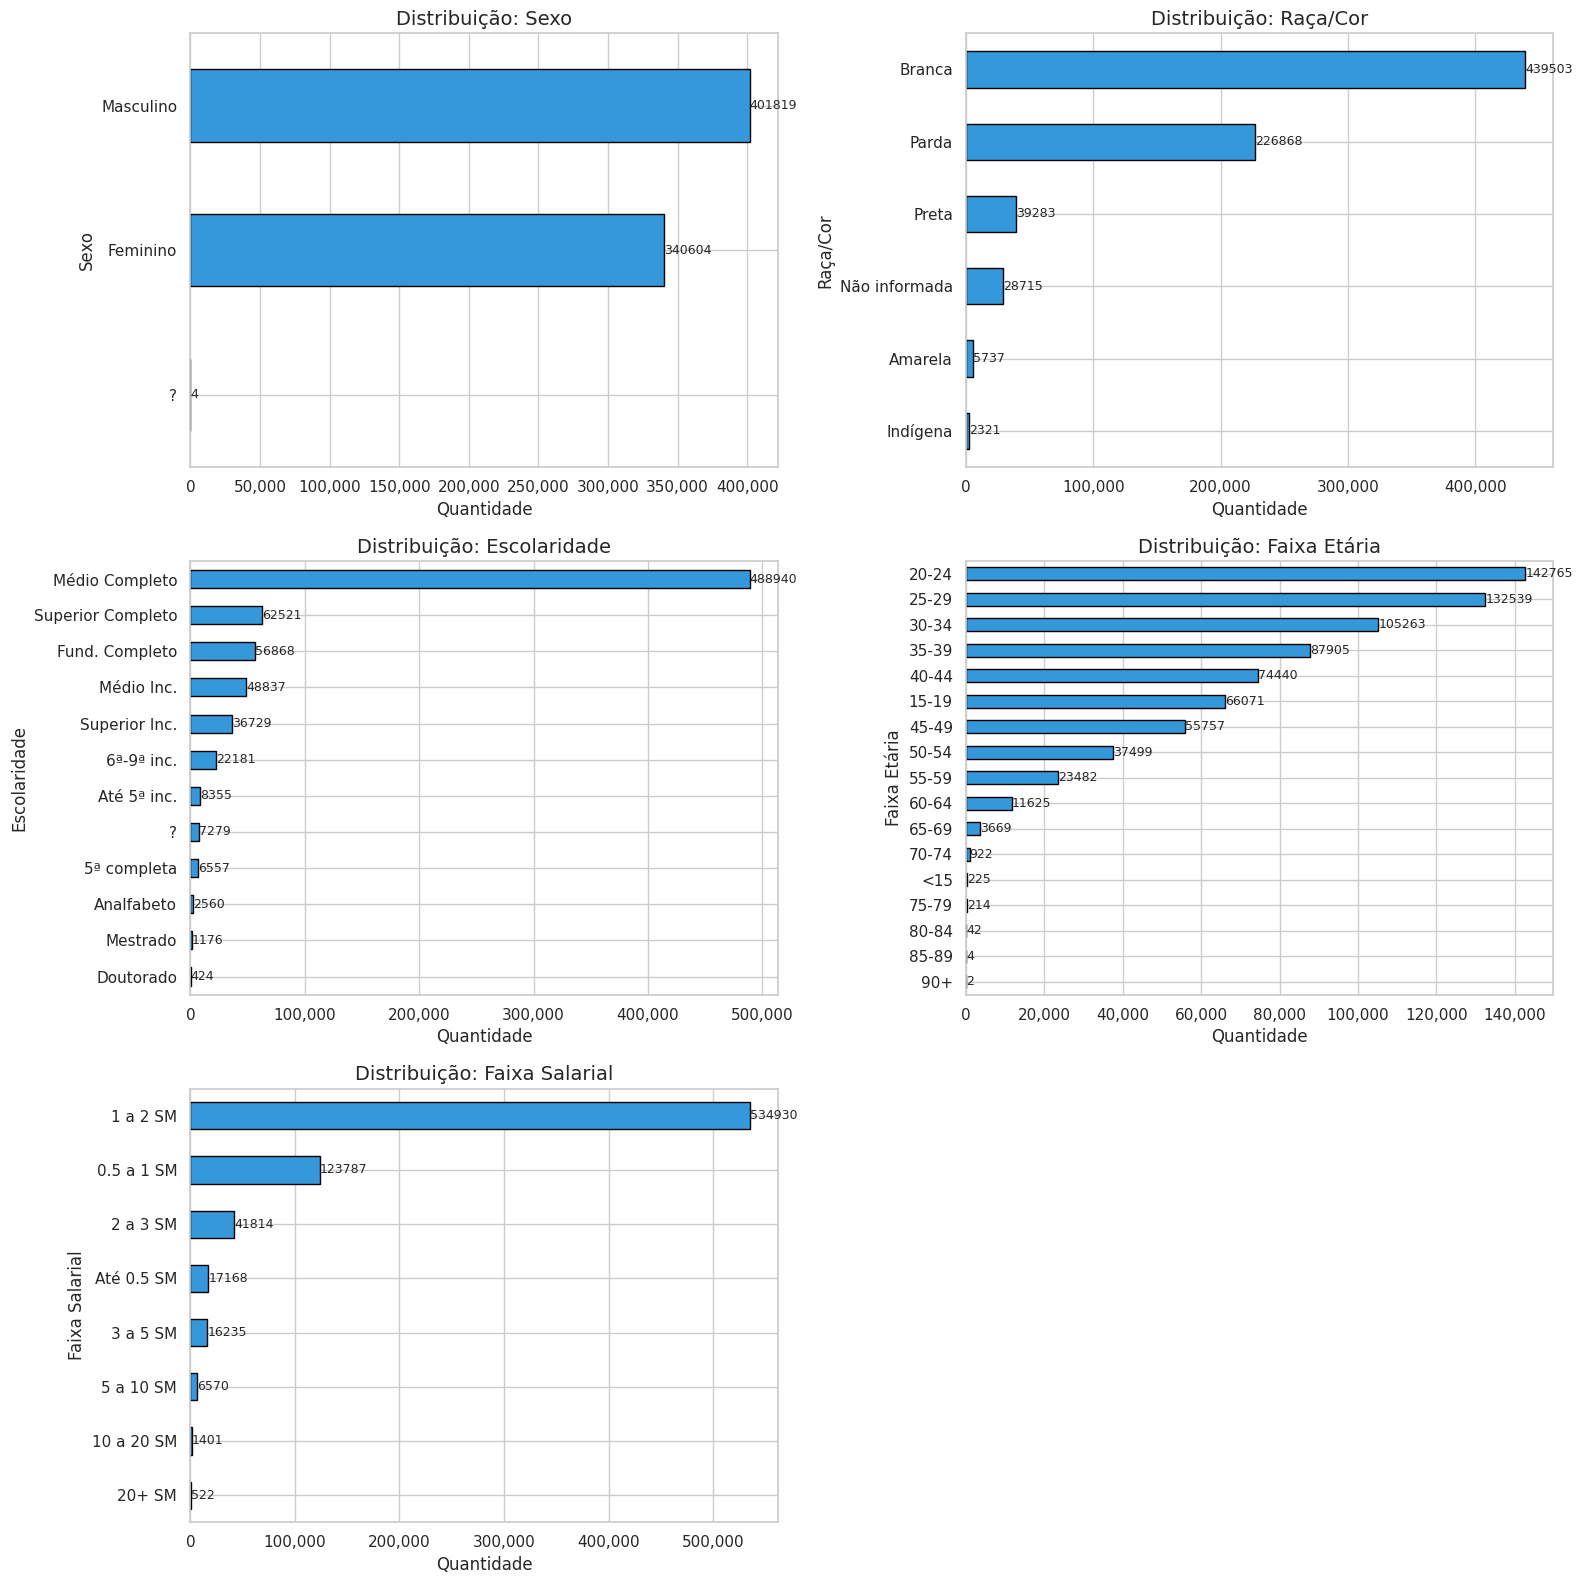

In [116]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.ravel()

for idx, (col, titulo) in enumerate(variaveis_cat):
    
    # ========================================================
    # Agrupamento: contagem total por categoria
    # ========================================================
    cat_total = df[col].value_counts().sort_values(ascending=True)
    
    # Gráfico: Distribuição simples
    cat_total.plot.barh(
        ax=axes[idx],
        color="#3498db",
        edgecolor="black"
    )
    axes[idx].set_title(f"Distribuição: {titulo}")
    axes[idx].set_xlabel("Quantidade")
    axes[idx].set_ylabel(titulo)
    
    # Formatador para milhares
    axes[idx].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    
    # Rótulos de contagem
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt="%d", label_type="edge", fontsize=9)

# Desabilitar o último subplot (vazio)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### Visualização de Proporção normalizada (stacked 100%) de admissões e desligamentos

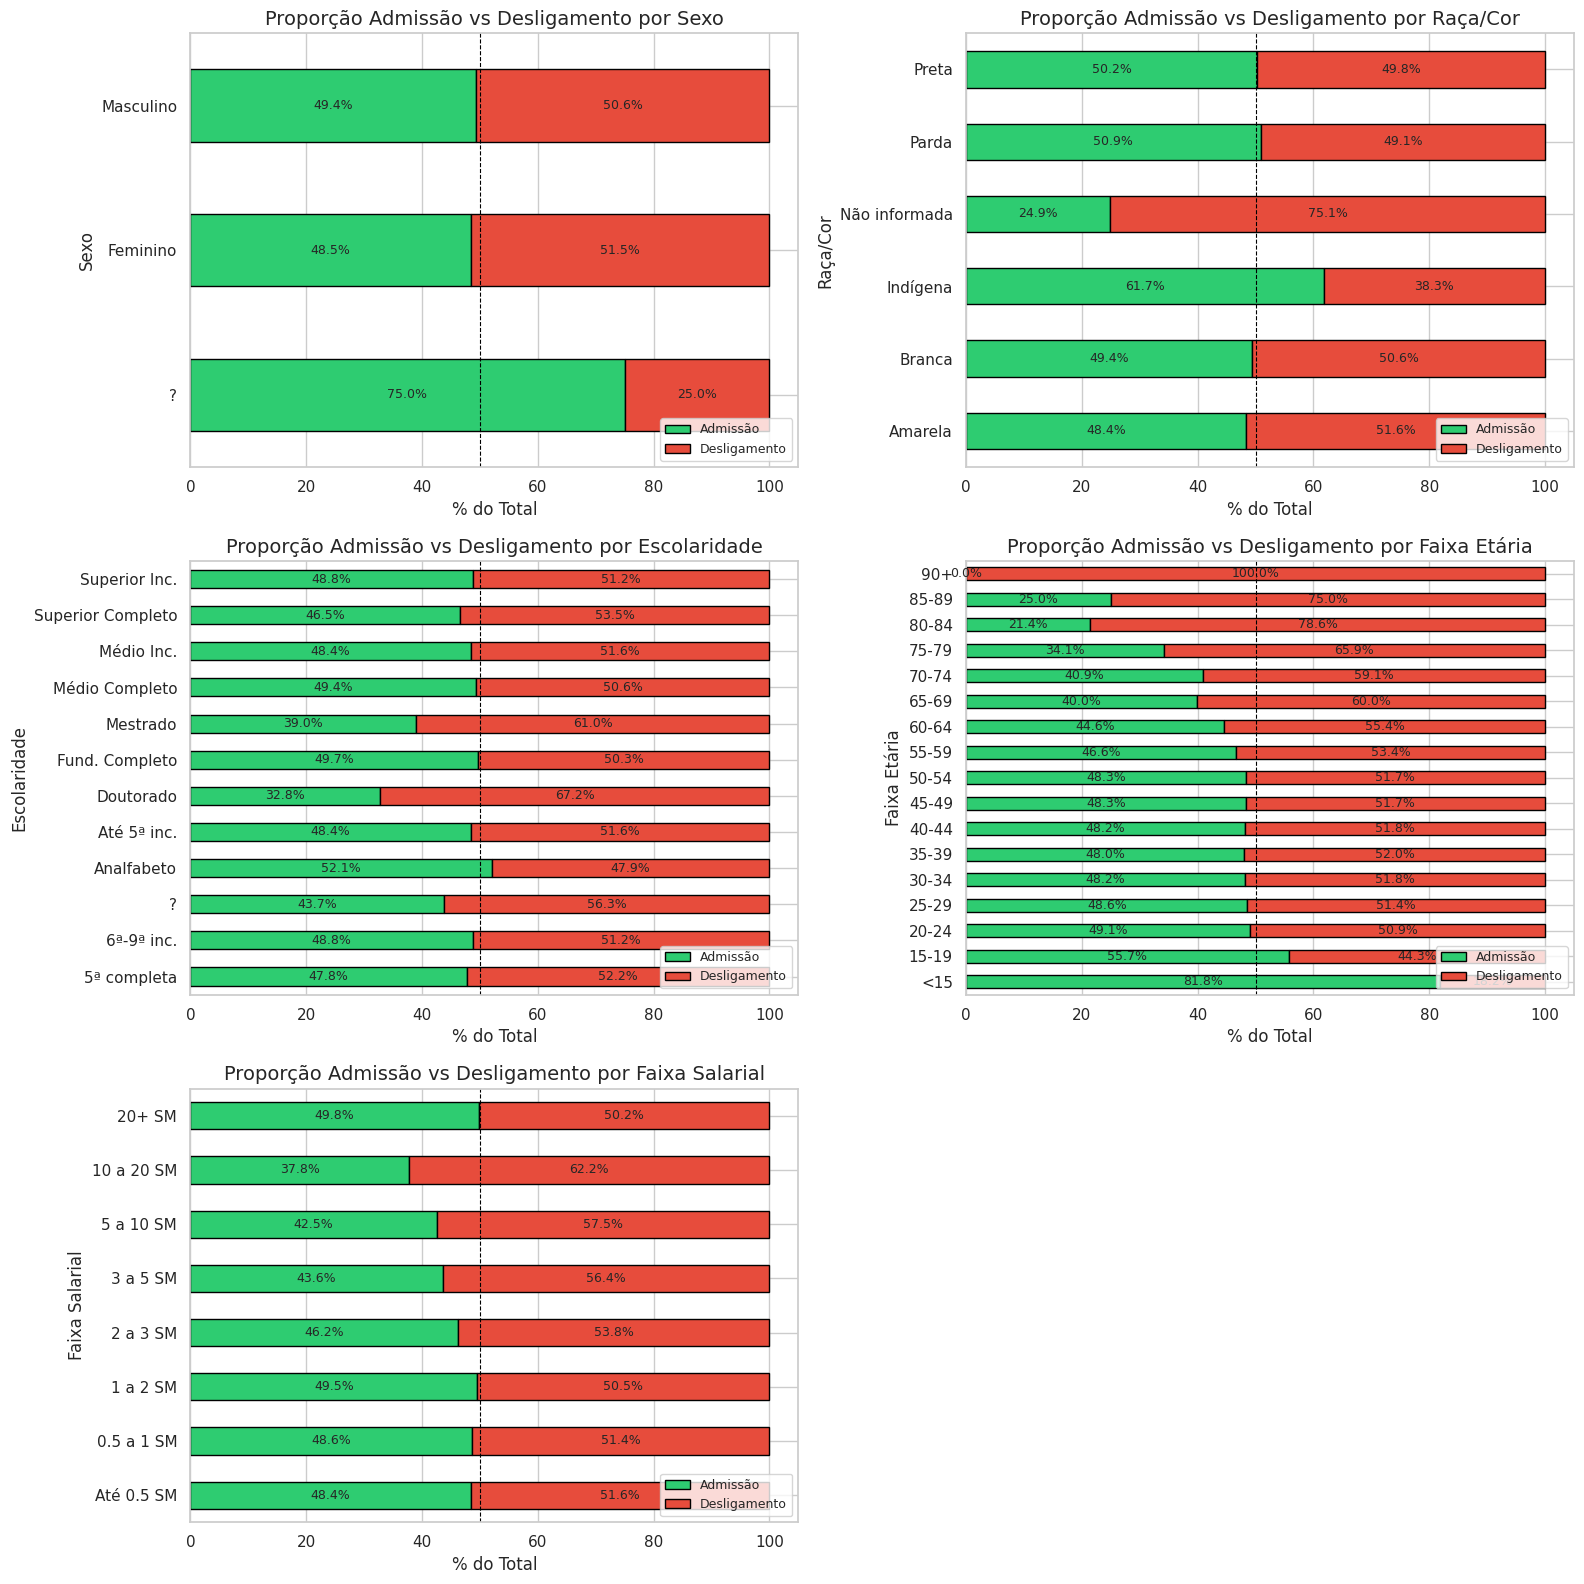

In [117]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.ravel()

for idx, (col, titulo) in enumerate(variaveis_cat):
    
    # ========================================================
    # Agrupamento: tabela de movimentação
    # ========================================================
    cat_saldo = (
        df.groupby([col, "saldomovimentacao"], observed=True)
        .size()
        .unstack(fill_value=0)
        .rename(columns=MAP_SALDO)
    )
    
    # Garantir colunas de Admissão e Desligamento
    for col_name in ["Admissão", "Desligamento"]:
        if col_name not in cat_saldo:
            cat_saldo[col_name] = 0
    
    # Proporção normalizada para gráficos
    cat_pct = cat_saldo[["Admissão", "Desligamento"]].div(
        cat_saldo[["Admissão", "Desligamento"]].sum(axis=1), axis=0
    ) * 100
    
    # Gráfico: Proporção normalizada (stacked 100%)
    cat_pct.plot.barh(
        ax=axes[idx],
        stacked=True,
        color=["#2ecc71", "#e74c3c"],
        edgecolor="black"
    )
    axes[idx].axvline(50, color="black", linestyle="--", linewidth=0.8)
    axes[idx].set_title(f"Proporção Admissão vs Desligamento por {titulo}")
    axes[idx].set_xlabel("% do Total")
    axes[idx].set_ylabel(titulo)
    axes[idx].legend(loc="lower right", fontsize=9)
    
    # Rótulos de porcentagem
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9)

# Desabilitar o último subplot (vazio)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


## 14. Conclusões e Insights

Resumo dos principais achados desta análise exploratória:

**Qualidade dos dados:**
- Verificar percentual de valores ausentes e duplicatas identificados acima.
- A coluna `horascontratuais` pode conter valores com vírgula como separador decimal.
- Checar valores inesperados em variáveis categóricas.

**Variável-alvo (`saldomovimentacao`):**
- O target é binário (1 = admissão, -1 = desligamento). Avaliar o desbalanceamento entre as classes.

**Padrões temporais:**
- O volume de movimentação varia significativamente entre competências.
- Os meses recomendados (nov, dez, jan) devem ser priorizados; os demais servem como contexto.

**Perfil demográfico:**
- Analisar diferenças de taxa de admissão entre sexo, raça/cor, faixa etária e escolaridade.
- O salário médio varia conforme grau de instrução e setor econômico.

**Para a modelagem:**
- Alta cardinalidade em `cbo2002ocupacao`, `subclasse` e `municipio` — considerar agrupamentos.
- Variáveis binárias com baixa frequência de 1 (intermitente, parcial, aprendiz, deficiência) podem ter pouco poder preditivo individual.
- A correlação linear com o target tende a ser baixa, sinalizando a necessidade de modelos não-lineares.
- Verificar a distribuição do dataset de teste para garantir compatibilidade com o treino.